# Sales Analysis — Portfolio Project (SQL + Python + Power BI)

**Project goal:** simulate the typical workflow of a data analyst:
1. Receive raw data with real capture errors.
2. Clean and prepare it with Python (pandas).
3. Load it into a SQL database for analysis.
4. Build an interactive dashboard in Power BI.

**This notebook covers steps 1 and 2.**

Dataset: synthetic sales data for a retail company operating across several
Mexican states, with Furniture / Office Supplies / Technology categories
(structure inspired by the well-known "Superstore" dataset used in BI
portfolios, but generated and localized to Mexico).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)


## 1. Load the raw data

In [2]:
sales = pd.read_csv("../data/raw/sales_raw.csv", parse_dates=["order_date", "ship_date"])
customers = pd.read_csv("../data/raw/customers_raw.csv")
products = pd.read_csv("../data/raw/products_raw.csv")

print(sales.shape, customers.shape, products.shape)
sales.head()


(3434, 10) (260, 6) (20, 6)


,order_id,order_date,ship_date,ship_mode,customer_id,product_id,quantity,discount,sales,profit
0,MX-01667,2026-04-28,2026-04-29,Standard Class,CU-0122,PR-016,8,0.00,9796.80,3556.80
1,MX-01277,2025-10-05,2025-10-09,Second Class,CU-0035,PR-011,1,0.00,250.50,100.50
2,MX-01939,2023-11-01,2023-11-06,Standard Class,CU-0223,PR-015,8,0.30,2867.20,307.20
3,MX-00106,2025-08-11,2025-08-15,NaN,CU-0247,PR-018,3,0.10,56376.00,12876.00
4,MX-00336,2023-12-22,2023-12-25,Second Class,CU-0047,PR-007,1,0.15,526.49,146.49


## 2. Data quality check

Before cleaning anything, it's worth understanding exactly what's broken.

In [3]:
print("Duplicate rows:", sales.duplicated().sum())
print()
print("Nulls per column:")
print(sales.isna().sum())
print()
print("Unique values in ship_mode (note the inconsistent text):")
print(sales["ship_mode"].unique())


Duplicate rows: 40

Nulls per column:
order_id        0
order_date      0
ship_date       0
ship_mode      68
customer_id     0
product_id      0
quantity        0
discount       51
sales           0
profit          0
dtype: int64

Unique values in ship_mode (note the inconsistent text):
<StringArray>
[  'Standard Class',     'Second Class',                nan,
      'First Class',         'Same Day', ' Standard Class ',
   ' Second Class ',      'FIRST CLASS',    ' First Class ',
   'STANDARD CLASS',       ' Same Day ',         'same day',
     'SECOND CLASS',     'second class',   'standard class',
         'SAME DAY',      'first class']
Length: 17, dtype: str


In [4]:
print("Negative quantities (capture error):", (sales["quantity"] < 0).sum())
print("Rows where ship_date < order_date (impossible):", (sales["ship_date"] < sales["order_date"]).sum())

# Outliers in 'sales' using the IQR method
q1, q3 = sales["sales"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
print(f"IQR upper bound for 'sales': {upper_bound:,.2f}")
print("Rows above the bound (likely outliers):", (sales["sales"] > upper_bound).sum())


Negative quantities (capture error): 15
Rows where ship_date < order_date (impossible): 10
IQR upper bound for 'sales': 35,665.40
Rows above the bound (likely outliers): 340


## 3. Cleaning

Rules applied (documented so anyone can audit the process):

- **Exact duplicates** → dropped.
- **`ship_mode`**: text is normalized (whitespace, casing) and nulls are
  imputed with the mode, since they represent less than 2% of the data.
- **`discount`**: nulls are imputed as `0` (no discount), the most common
  category.
- **Negative `quantity`**: a known capture error (flipped sign) → fixed with
  the absolute value instead of dropping the row, since the rest of the row
  is valid.
- **`sales` outliers**: recalculated from `profit` and the product's cost
  instead of being discarded, to avoid losing real order information.
- **`ship_date` earlier than `order_date`**: a logical capture error → fixed
  by adding the median shipping time from the rest of the dataset.


In [5]:
df = sales.copy()

# Duplicates
df = df.drop_duplicates()

# Normalize ship_mode text
df["ship_mode"] = (
    df["ship_mode"]
    .astype(str)
    .str.strip()
    .str.title()
    .replace({"Nan": np.nan})
)

mode_ship = df["ship_mode"].mode()[0]
df["ship_mode"] = df["ship_mode"].fillna(mode_ship)

# Null discount -> 0
df["discount"] = df["discount"].fillna(0)

# Negative quantity -> absolute value
df["quantity"] = df["quantity"].abs()

# Recalculate sales outliers using profit + product unit cost
df = df.merge(products[["product_id", "unit_cost"]], on="product_id", how="left")
outliers_mask = df["sales"] > upper_bound
df.loc[outliers_mask, "sales"] = (
    df.loc[outliers_mask, "unit_cost"] * df.loc[outliers_mask, "quantity"]
    + df.loc[outliers_mask, "profit"]
)
df = df.drop(columns=["unit_cost"])

# Inconsistent ship dates
median_ship_days = (sales["ship_date"] - sales["order_date"]).dt.days.median()
bad_dates = df["ship_date"] < df["order_date"]
df.loc[bad_dates, "ship_date"] = df.loc[bad_dates, "order_date"] + pd.to_timedelta(median_ship_days, unit="D")

# Second duplicate pass: imputing nulls can reveal rows that are now exact
# duplicates (e.g. two copies of the same order where one had a null
# discount and the other had 0 -- after imputing, they become identical)
df = df.drop_duplicates()

print("Rows after cleaning:", len(df))


Rows after cleaning: 3386


### Quick post-cleaning validation

In [6]:
assert df.isna().sum().sum() == 0, "There are still nulls"
assert (df["quantity"] < 0).sum() == 0, "There are still negative quantities"
assert (df["ship_date"] < df["order_date"]).sum() == 0, "There are still inconsistent dates"
assert df.duplicated().sum() == 0, "There are still duplicates"
print("All validations passed.")


All validations passed.


## 4. Enrich: join with customers and products, create derived columns

In [7]:
df = df.merge(customers, on="customer_id", how="left")
df = df.merge(products, on="product_id", how="left")

df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["year_month"] = df["order_date"].dt.strftime("%Y-%m")
df["quarter"] = df["order_date"].dt.quarter
df["ship_days"] = (df["ship_date"] - df["order_date"]).dt.days
df["profit_margin"] = (df["profit"] / df["sales"]).round(4)

df.head()


,order_id,order_date,ship_date,ship_mode,customer_id,product_id,quantity,discount,sales,profit,customer_name,segment,state,city,region,category,subcategory,product_name,unit_cost,base_margin,year,month,year_month,quarter,ship_days,profit_margin
0,MX-01667,2026-04-28,2026-04-29,Standard Class,CU-0122,PR-016,8,0.00,9796.80,3556.80,Ana Sanchez,Home Office,Queretaro,Queretaro,Central,Technology,Accessories,Compact Mechanical Keyboard,780,0.22,2026,4,2026-04,2,1,0.3631
1,MX-01277,2025-10-05,2025-10-09,Second Class,CU-0035,PR-011,1,0.00,250.50,100.50,Juan Hernandez,Consumer,Oaxaca,Oaxaca City,South,Office Supplies,Art,Professional Marker Set,150,0.32,2025,10,2025-10,4,4,0.4012
2,MX-01939,2023-11-01,2023-11-06,Standard Class,CU-0223,PR-015,8,0.30,2867.20,307.20,Paola Gonzalez,Consumer,Baja California,Tijuana,North,Technology,Accessories,Wireless Mouse,320,0.25,2023,11,2023-11,4,5,0.1071
3,MX-00106,2025-08-11,2025-08-15,Standard Class,CU-0247,PR-018,3,0.10,56376.00,12876.00,Mariana Reyes,Consumer,Quintana Roo,Cancun,South,Technology,Machines,14'' Business Laptop,14500,0.09,2025,8,2025-08,3,4,0.2284
4,MX-00336,2023-12-22,2023-12-25,Second Class,CU-0047,PR-007,1,0.15,526.49,146.49,Daniela Alvarez,Corporate,Nuevo Leon,Monterrey,North,Office Supplies,Paper,A4 Bond Paper Pack (5000 sheets),380,0.28,2023,12,2023-12,4,3,0.2782


## 5. Exploratory data analysis (EDA)

In [8]:
summary = {
    "Total sales (MXN)": df["sales"].sum(),
    "Total profit (MXN)": df["profit"].sum(),
    "Unique orders": df["order_id"].nunique(),
    "Average order value (MXN)": df.groupby("order_id")["sales"].sum().mean(),
    "Average margin": df["profit_margin"].mean(),
}
for k, v in summary.items():
    print(f"{k}: {v:,.2f}" if "average" in k.lower() else f"{k}: {v:,.0f}")


Total sales (MXN): 46,124,858
Total profit (MXN): 12,111,150
Unique orders: 2,200
Average order value (MXN): 20,965.84
Average margin: 0.28


In [9]:
sales_by_category = df.groupby("category")[["sales", "profit"]].sum().sort_values("sales", ascending=False)
sales_by_category


,sales,profit
category,,
Technology,28377152.47,7112992.47
Furniture,13930359.29,3804459.29
Office Supplies,3817346.60,1193698.07


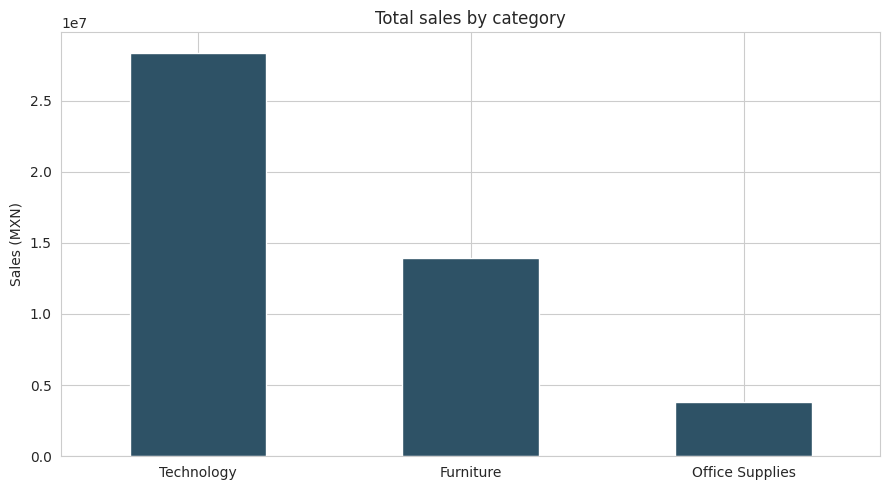

In [10]:
fig, ax = plt.subplots()
sales_by_category["sales"].plot(kind="bar", ax=ax, color="#2E5266")
ax.set_title("Total sales by category")
ax.set_ylabel("Sales (MXN)")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../data/clean/chart_sales_by_category.png", dpi=120)
plt.show()


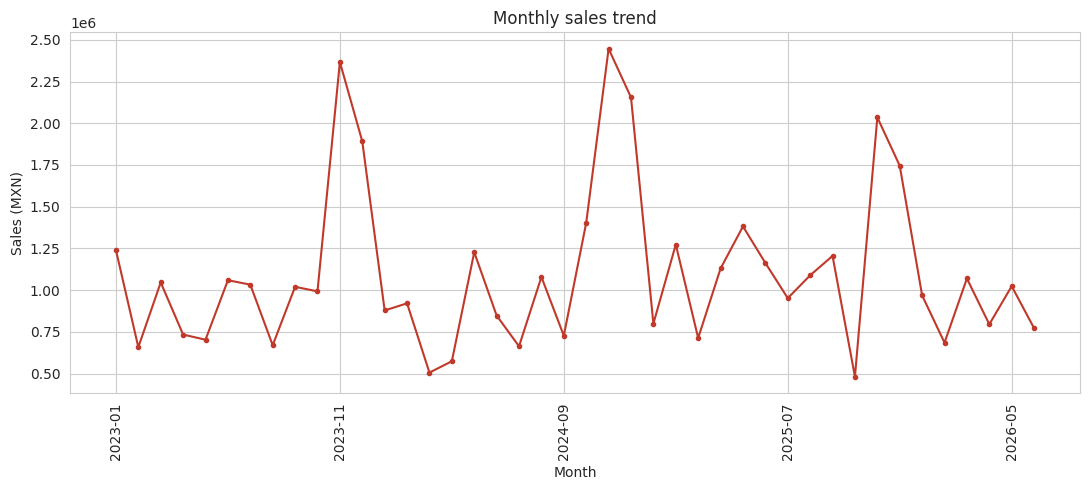

In [11]:
monthly_trend = df.groupby("year_month")["sales"].sum().sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
monthly_trend.plot(ax=ax, color="#C0392B", marker="o", markersize=3)
ax.set_title("Monthly sales trend")
ax.set_ylabel("Sales (MXN)")
ax.set_xlabel("Month")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../data/clean/chart_monthly_trend.png", dpi=120)
plt.show()


In [12]:
top_products = (
    df.groupby("product_name")[["sales", "profit"]]
    .sum()
    .sort_values("sales", ascending=False)
    .head(10)
)
top_products


,sales,profit
product_name,,
14'' Business Laptop,15700716.00,3781716.00
Laser All-in-One Printer,6910881.25,1665381.25
8-Person Conference Table,4453306.20,1206706.20
L-Shaped Desk,3787699.20,1000499.20
24'' Full HD Monitor,3145590.00,905590.00
5-Tier Modular Bookcase,2172927.75,591627.75
ErgoMax Executive Chair,2006151.30,584151.30
3-Drawer File Cabinet,1531060.02,481260.02
Office IP Phone,1313665.65,368765.65


### Key insight: discounts eat into profit

A typical (and real) finding in this kind of dataset: high discounts don't
always translate into more profit — they can even cause a net loss.

discount_range
No discount        0.356621
Low (1-15%)        0.272806
Medium (16-30%)    0.151146
High (>30%)       -0.126001
Name: profit_margin, dtype: float64


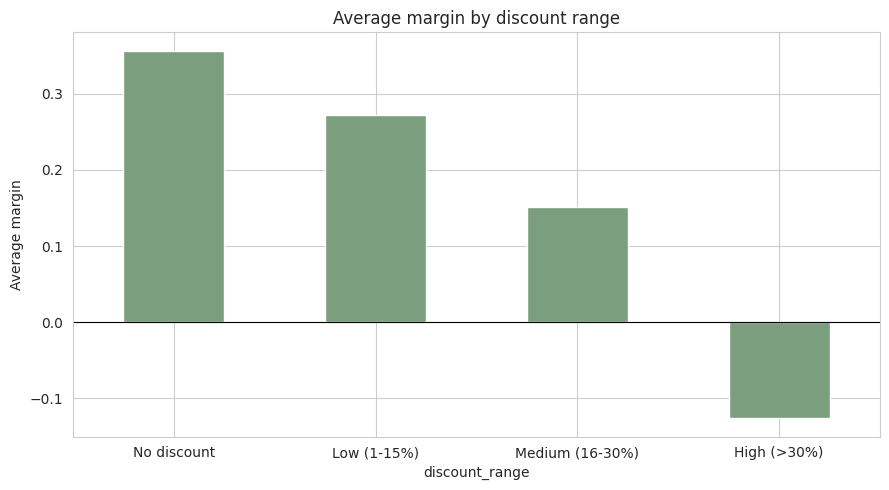

In [13]:
bins = [-0.01, 0, 0.15, 0.3, 1]
labels = ["No discount", "Low (1-15%)", "Medium (16-30%)", "High (>30%)"]
df["discount_range"] = pd.cut(df["discount"], bins=bins, labels=labels)

margin_by_discount = df.groupby("discount_range", observed=True)["profit_margin"].mean()
print(margin_by_discount)

fig, ax = plt.subplots()
margin_by_discount.plot(kind="bar", ax=ax, color="#7A9E7E")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Average margin by discount range")
ax.set_ylabel("Average margin")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../data/clean/chart_margin_by_discount.png", dpi=120)
plt.show()


In [14]:
sales_by_region = df.groupby("region")[["sales", "profit"]].sum().sort_values("sales", ascending=False)
sales_by_region


,sales,profit
region,,
North,14280288.24,3588173.71
Central,12258413.96,3310353.96
South,11939510.23,3164446.23
West,7646645.93,2048175.93


## 6. Export the star-schema model

Separate tables (one fact table + dimensions) are exported because:
- It's the format Power BI expects to model relationships and write DAX
  efficiently.
- It's exactly what gets loaded into SQL in the next step of the project.


In [15]:
dim_customer = df[["customer_id", "customer_name", "segment"]].drop_duplicates().reset_index(drop=True)
dim_location = df[["customer_id", "state", "city", "region"]].drop_duplicates().reset_index(drop=True)
dim_product = df[["product_id", "category", "subcategory", "product_name"]].drop_duplicates().reset_index(drop=True)

dim_date = pd.DataFrame({"date": pd.date_range(df["order_date"].min(), df["order_date"].max())})
dim_date["date_id"] = dim_date["date"].dt.strftime("%Y%m%d").astype(int)
dim_date["year"] = dim_date["date"].dt.year
dim_date["month"] = dim_date["date"].dt.month
dim_date["month_name"] = dim_date["date"].dt.strftime("%B")
dim_date["quarter"] = dim_date["date"].dt.quarter
dim_date["year_month"] = dim_date["date"].dt.strftime("%Y-%m")

fact_sales = df[[
    "order_id", "order_date", "ship_date", "ship_mode", "customer_id",
    "product_id", "quantity", "discount", "sales", "profit", "ship_days", "profit_margin",
]].copy()
fact_sales["date_id"] = fact_sales["order_date"].dt.strftime("%Y%m%d").astype(int)

fact_sales.to_csv("../data/clean/fact_sales.csv", index=False)
dim_customer.to_csv("../data/clean/dim_customer.csv", index=False)
dim_location.to_csv("../data/clean/dim_location.csv", index=False)
dim_product.to_csv("../data/clean/dim_product.csv", index=False)
dim_date.to_csv("../data/clean/dim_date.csv", index=False)

print("Tables exported to data/clean/:")
print(f"  fact_sales:    {len(fact_sales):,} rows")
print(f"  dim_customer:  {len(dim_customer):,} rows")
print(f"  dim_location:  {len(dim_location):,} rows")
print(f"  dim_product:   {len(dim_product):,} rows")
print(f"  dim_date:      {len(dim_date):,} rows")


Tables exported to data/clean/:
  fact_sales:    3,386 rows
  dim_customer:  260 rows
  dim_location:  260 rows
  dim_product:   20 rows
  dim_date:      1,276 rows


## Next steps

1. **SQL** (`/sql`): these same tables are loaded into a SQLite database to
   practice aggregations, JOINs, window functions and CTEs.
2. **Power BI** (`/powerbi`): these clean tables are imported directly to
   build the data model (star schema) and the dashboard.
